# Import libraries

In [1]:
import sys
github_repo_url = "https://github.com/AnnaEls/HAADF-STEM-image-denoising.git"
!git clone {github_repo_url}
sys.path.append('/content/HAADF-STEM-image-denoising')

Cloning into 'HAADF-STEM-image-denoising'...
remote: Enumerating objects: 840, done.
remote: Counting objects: 100% (436/436), done.
remote: Compressing objects: 100% (428/428), done.
remote: Total 840 (delta 219), reused 0 (delta 0), pack-reused 404 (from 2)
Receiving objects: 100% (840/840), 35.71 MiB | 9.63 MiB/s, done.
Resolving deltas: 100% (321/321), done.


In [ ]:
!pip install hyperspy
!pip install atomap

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import h5py
import tifffile
from Models.hybrid_model import hybrid_model
from Models.UNet import init_unet_kaiming
from Utilities.Utils import prepare_input, convert
from Training.Training import train_hybrid_model

import hyperspy.api as hs
import atomap as am
from Analysis.gaussian_detection_atomap import find_atoms, compare_sublattices_with_lattice_fp_classification, plot_atom_classification

/usr/local/lib/python3.13/dist-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


# Settting parameters

In [4]:
#PARAMETERS
#Type of study
STUDY = 'DEFAULT_PARAMETERS'
#Model parameters
WIDTH = 'DEFAULT'
DEPTH = 'DEFAULT'
DEPTH_CNN = 'DEFAULT'
MODEL = hybrid_model()
init_unet_kaiming(MODEL)
#Masking parameters
PATCH_SIZE = 7
MASK_RATIO = 0.2
#Training parameters
LR = 1e-3
NUM_EPOCHS = 300
NUM_RUNS = 1

In [5]:
dataset_path = '/content/HAADF-STEM-image-denoising/Datasets/'
data_file = dataset_path + 'wei_atom_subset_WS2_contrast_variation.h5'

metadata_subset = pd.read_hdf(data_file, key="metadata")

with h5py.File(data_file, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("Images:", list(f["imgs"].keys()))
    print("Raw:", list(f["raw"].keys()))
    print("Coordinates:", list(f["coords"].keys()))

print("\nMetadata:")
display(metadata_subset)

Top-level keys: ['coords', 'imgs', 'metadata', 'raw']
Images: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']
Raw: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']
Coordinates: ['0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130']

Metadata:


,key,Atoms/px,Material_orientation,Spacegroup,Type,contrast,dose_e-/Å²,peakintensity_e-,pixelsize_pm,probe_current_pA,resolution_pm,flybackerror,poisson_dB,randomdrift
123,0123,8.393051,WS2[0001],P63/mmc[194],experimental,0.159,116783.034798,2502.422276,15.46,22.33,98.0,NaN,NaN,NaN
124,0124,8.393051,WS2[0001],P63/mmc[194],experimental,0.133,116783.034798,2365.907658,15.46,22.33,98.0,NaN,NaN,NaN
125,0125,8.393051,WS2[0001],P63/mmc[194],experimental,0.101,116783.034798,2229.216597,15.46,22.33,98.0,NaN,NaN,NaN
126,0126,8.393051,WS2[0001],P63/mmc[194],experimental,0.060,116783.034798,3164.079849,15.46,22.33,98.0,NaN,NaN,NaN
127,0127,8.393051,WS2[0001],P63/mmc[194],experimental,0.048,116783.034798,4146.385107,15.46,22.33,98.0,NaN,NaN,NaN
128,0128,8.393051,WS2[0001],P63/mmc[194],experimental,0.037,116783.034798,4616.112008,15.46,22.33,98.0,NaN,NaN,NaN
129,0129,8.393051,WS2[0001],P63/mmc[194],experimental,0.109,116783.034798,2270.713104,15.46,22.33,98.0,NaN,NaN,NaN
130,0130,8.393051,WS2[0001],P63/mmc[194],experimental,0.087,116783.034798,2179.196693,15.46,22.33,98.0,NaN,NaN,NaN


In [6]:
key = "0128"

with h5py.File(data_file, "r") as f:
    img = f["imgs"][key][:]
    raw = f["raw"][key][:]
    coords = f["coords"][key][:]

print("Image shape:", img.shape)
print("Raw shape:", raw.shape)
print("Coordinates shape:", coords.shape)

Image shape: (256, 256)
Raw shape: (256, 256)
Coordinates shape: (297, 2)


# Analysis

Image ID: 0123


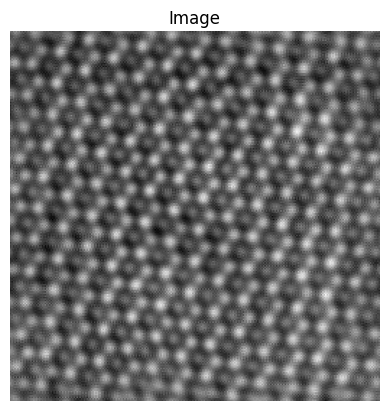

Image ID: 0124


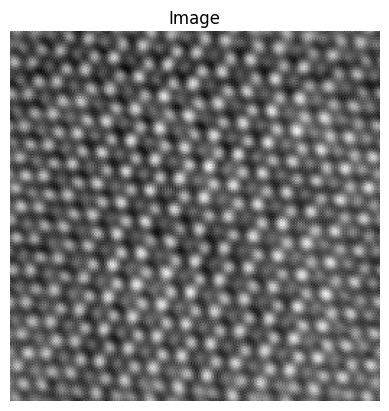

Image ID: 0129


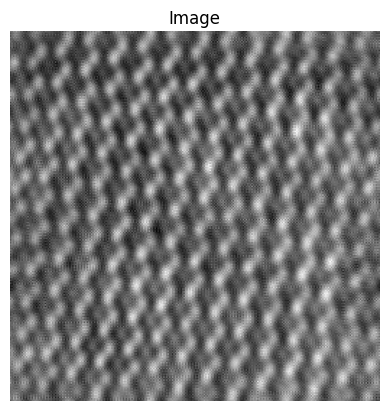

Image ID: 0125


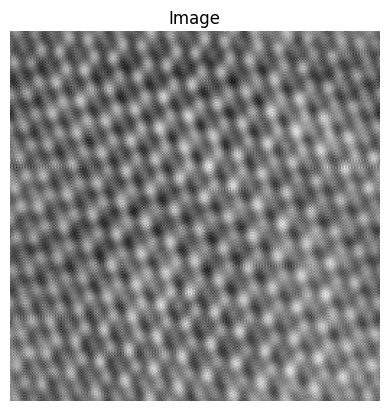

Image ID: 0130


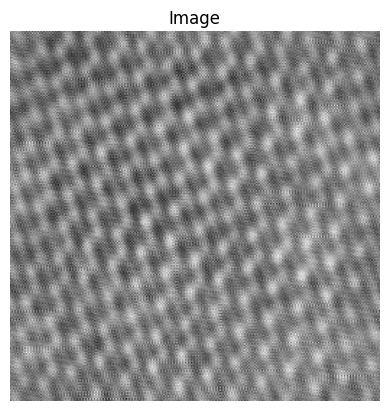

Image ID: 0126


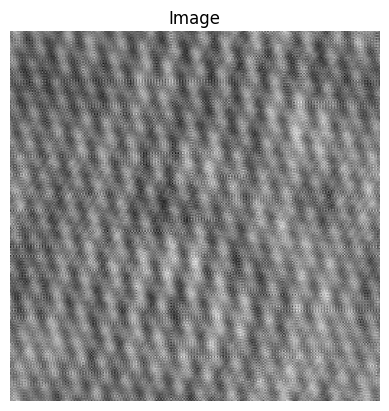

Image ID: 0127


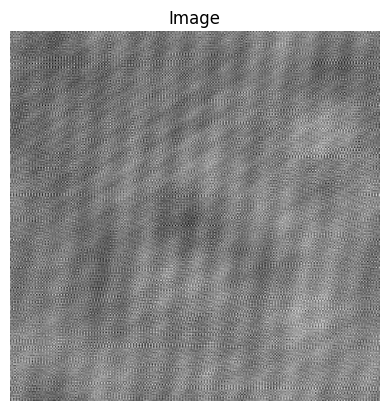

Image ID: 0128


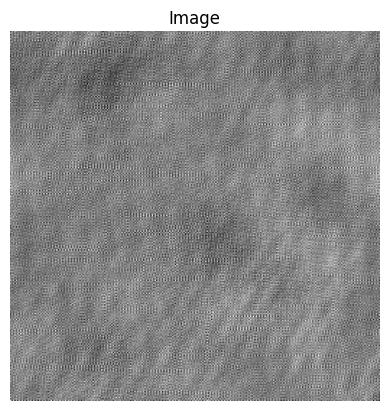

In [8]:
keys = ["0123", "0124", "0129", "0125", "0130", "0126", "0127", "0128"]
rows = []
for key in keys:
    print("Image ID:" , key)
    output_path = f"/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/RESULTS_OTHER_WORKS/PINTO/"
    image_path = output_path + "Image_ID_" + key + "_denoised_pinto.tif"
    image = tifffile.imread(image_path)
    plt.imshow(image, cmap = "gray"); plt.axis("off"); plt.title("Image")
    plt.show()

Image ID: 0123


Gaussian fitting: 100%|██████████| 435/435 [00:10<00:00, 40.68it/s]


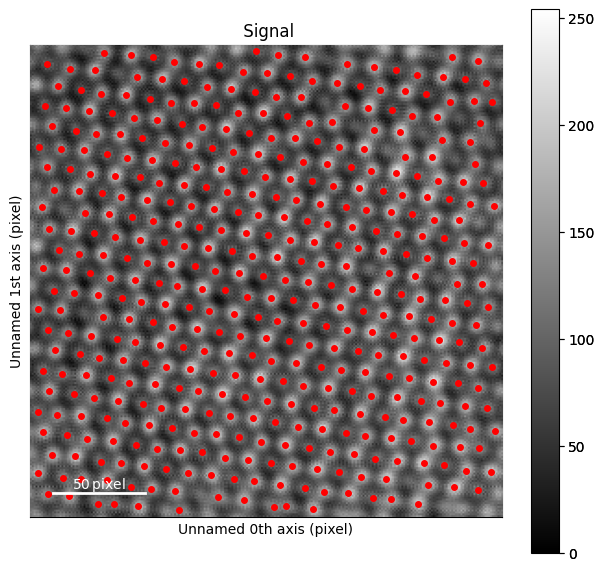

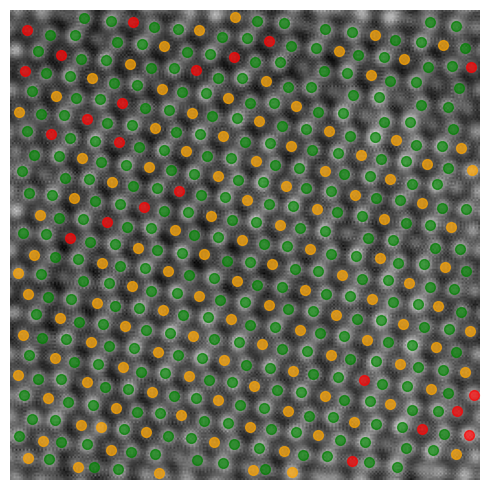

Image ID: 0124


Gaussian fitting: 100%|██████████| 435/435 [00:08<00:00, 53.03it/s]


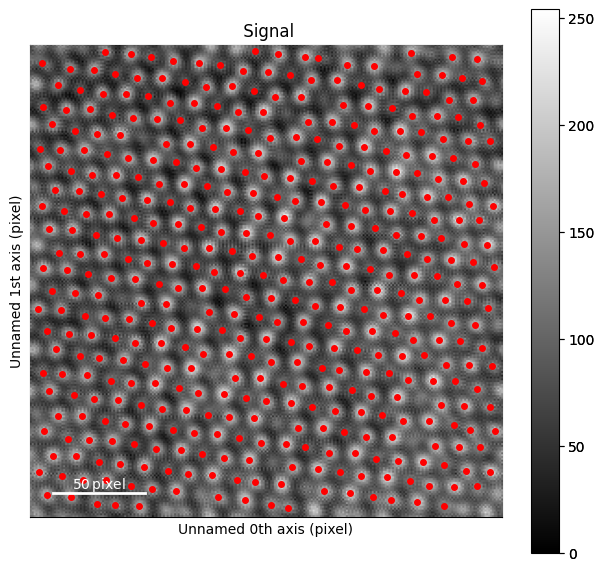

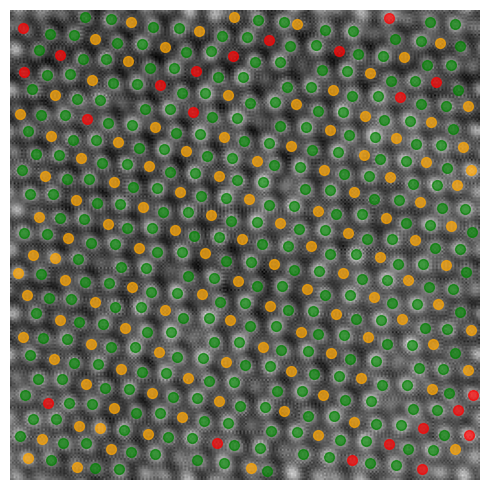

Image ID: 0125


Gaussian fitting:  28%|██▊       | 99/349 [00:01<00:04, 56.70it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 349/349 [00:07<00:00, 48.85it/s]


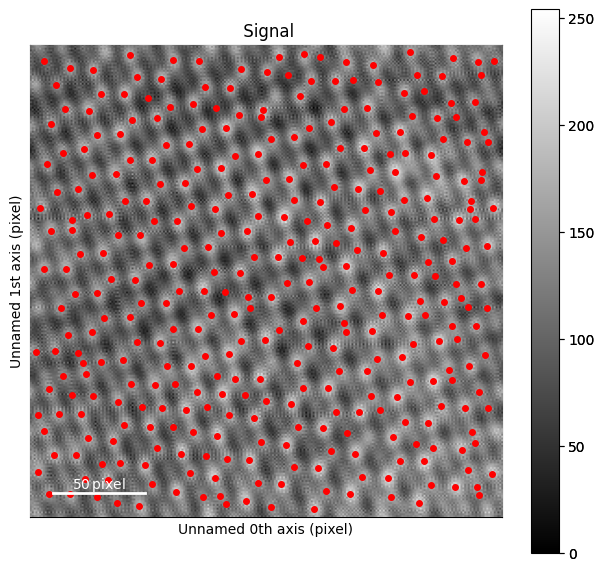

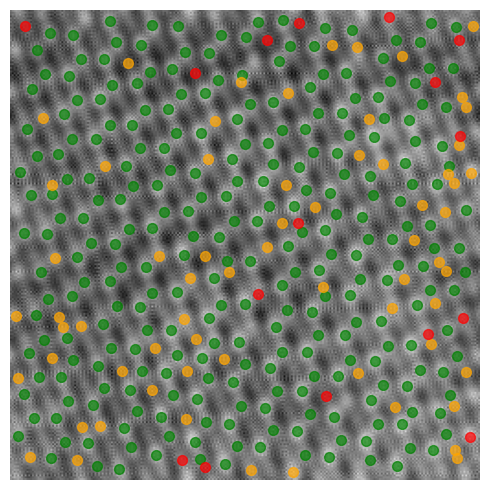

Image ID: 0126


Gaussian fitting:   4%|▍         | 21/475 [00:00<00:09, 50.23it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


...

WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting:  61%|██████    | 289/475 [00:11<00:12, 14.94it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 475/475 [00:16<00:00, 28.16it/s]


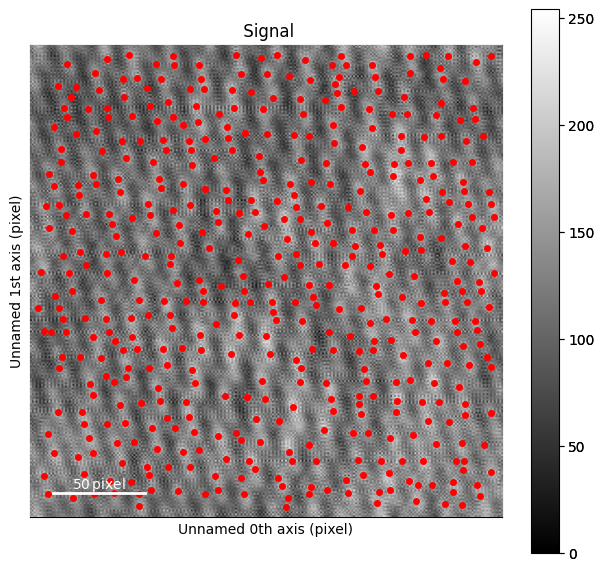

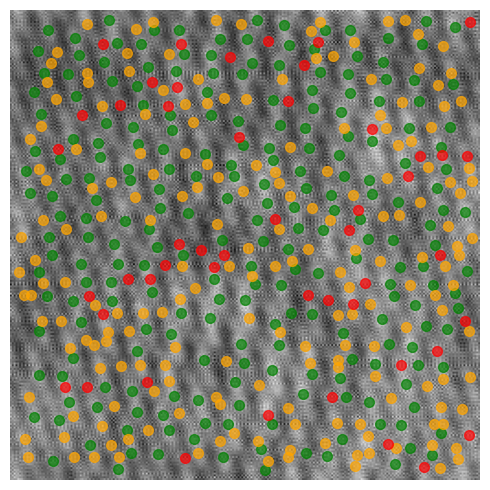

Image ID: 0127


Gaussian fitting:   2%|▏         | 11/646 [00:00<00:19, 33.21it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting:   9%|▊         | 55/646 [00:03<00:19, 30.65it/s]

...

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 646/646 [01:22<00:00,  7.80it/s]


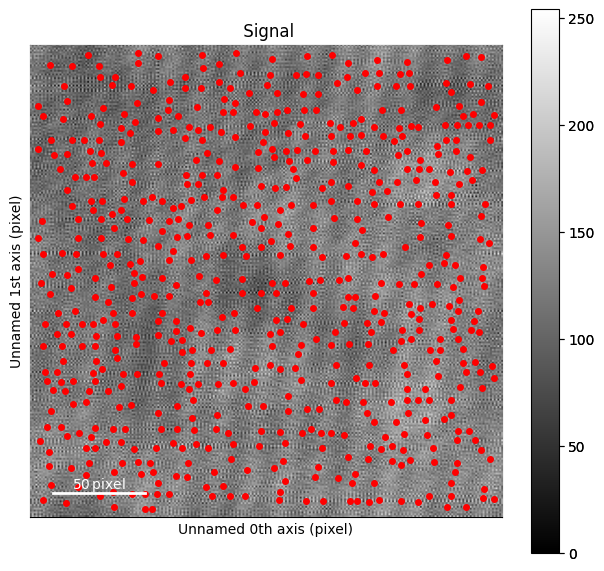

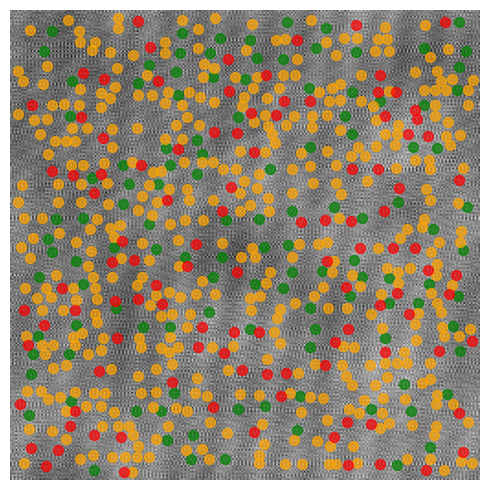

Image ID: 0128


Gaussian fitting:   2%|▏         | 14/691 [00:02<01:45,  6.41it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


...

WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting:  97%|█████████▋| 669/691 [01:24<00:01, 11.83it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 691/691 [01:24<00:00,  8.14it/s]


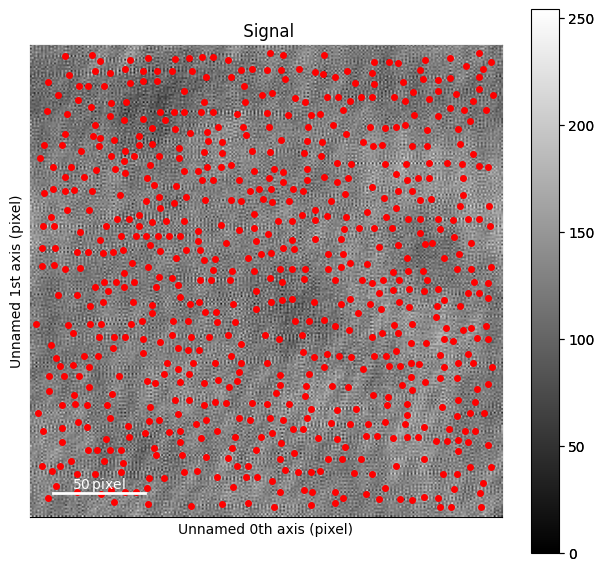

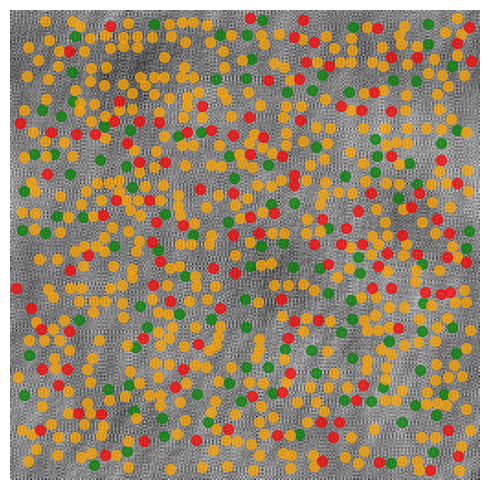

Image ID: 0129


Gaussian fitting:  83%|████████▎ | 278/335 [00:07<00:02, 24.57it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 335/335 [00:10<00:00, 32.98it/s]


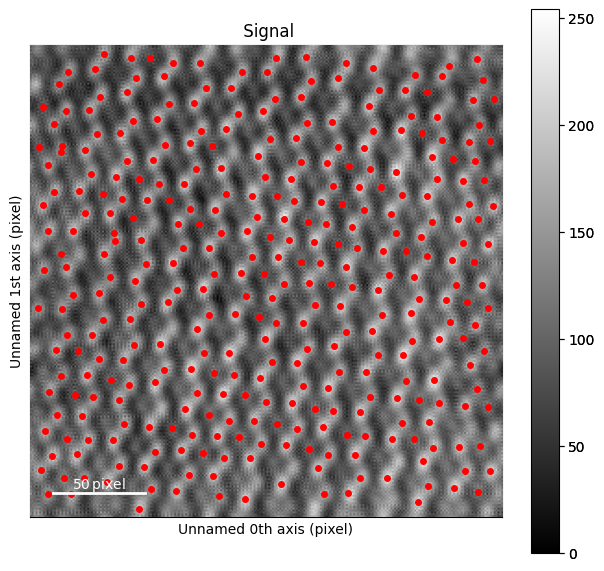

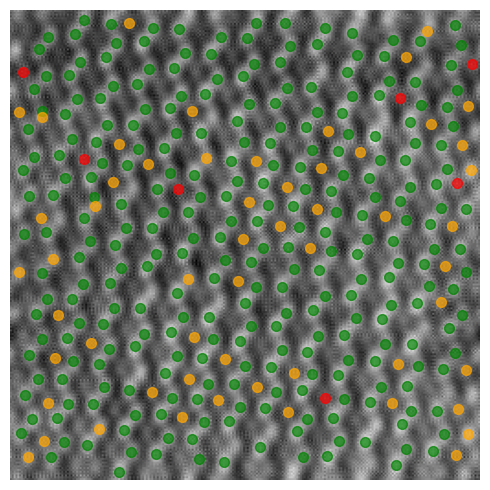

Image ID: 0130


Gaussian fitting:   1%|          | 4/361 [00:00<00:09, 37.35it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


...

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 361/361 [00:12<00:00, 29.43it/s]


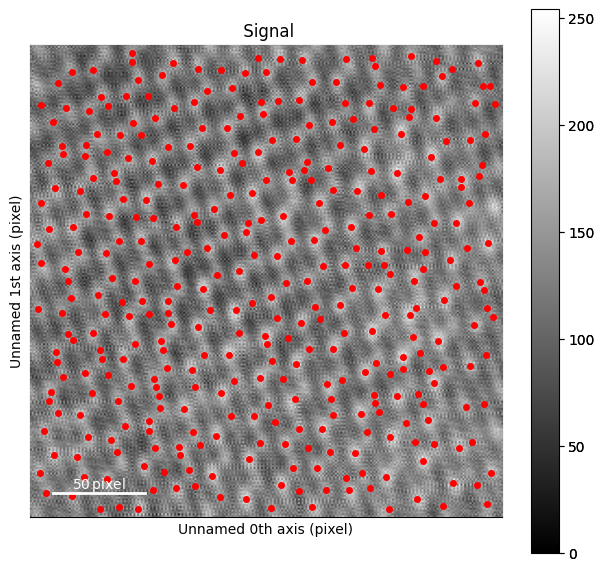

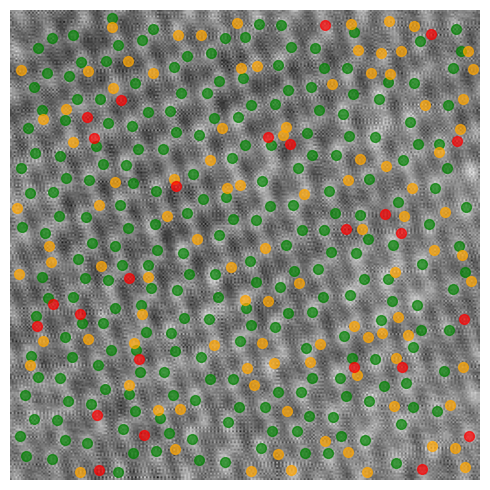

In [9]:
keys = ["0123", "0124", "0125", "0126", "0127", "0128", "0129", "0130"]
rows = []
for key in keys:
    print("Image ID:" , key)
    output_path = f"/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/RESULTS_OTHER_WORKS/PINTO/"
    image_path = output_path + "Image_ID_" + key + "_denoised_pinto.tif"
    image = tifffile.imread(image_path)
    s = hs.load(image_path)
    noisy_sublattice = find_atoms(s, separation = 4, plot = True)
    plt.show()
    atom_data = []
    for atom in noisy_sublattice.atom_list:
      atom_data.append({
        'x': atom.pixel_x,
        'y': atom.pixel_y,
        'sx': atom.sigma_x,
        'sy': atom.sigma_y,
        'r': atom.rotation,
        'e': atom.ellipticity,
        'amplitude_gaussian': atom.amplitude_gaussian
       })
    df_gaussians = pd.DataFrame(atom_data)
    df_gaussians.to_csv(output_path + 'gaussians_image_ID_' + key + '_denoised_pinto.csv', index=False)

    with h5py.File(data_file, "r") as f:
        coordinates = f["coords"][key][:]

    reference_sublattice = am.sublattice.Sublattice(
        atom_position_list=coordinates,
        image=image
     )
    results = compare_sublattices_with_lattice_fp_classification(
        reference_sublattice,
        noisy_sublattice,
        image_shape=image.shape,
        match_tolerance=3.0,
        lattice_tolerance=3.0,
        neighbor_radius=25)
    plot_atom_classification(image, reference_sublattice, noisy_sublattice, results)
    contrast = metadata_subset.loc[metadata_subset["key"] == key, "contrast"].values[0]
    rows.append({"image_ID": key, "contrast": contrast, "rmse": results["rmse_error"], "TP": results["num_true_positives"], "FN": results["num_false_negatives"], "FP": results["num_false_positives"], "rmse_norm": results["rmse_error"]/results["num_true_positives"] })

In [10]:
df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(by="contrast",ascending=False)
display(df_results)
output_path_results = "/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_WEI_ATOM_WS2_CONTRAST/"
df_results.to_csv(output_path_results + "gaussians_positions_evaluation_pinto_model.csv", index=False)

,image_ID,contrast,rmse,TP,FN,FP,rmse_norm
0,0123,0.159,0.912853,293,4,142,0.003116
1,0124,0.133,1.127099,293,4,142,0.003847
6,0129,0.109,1.276418,272,25,63,0.004693
2,0125,0.101,1.390201,267,30,82,0.005207
7,0130,0.087,1.557163,236,61,125,0.006598
3,0126,0.060,1.635665,230,67,245,0.007112
4,0127,0.048,2.100955,119,178,527,0.017655
5,0128,0.037,1.989355,117,180,574,0.017003
